# Deep Learning
## Lab Assignment 10 - Weather Prediction using LSTM
Name: Ruta Lole

Roll no.: 61

PRN: 12310305

Class: TY CSAI-A

Batch: 3

## Title:
Using LSTM for prediction of future weather of cities in Python

In [1]:
import sys

!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn kagglehub tensorflow seaborn


[notice] A new release of pip available: 22.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sumanthvrao/daily-climate-time-series-data")

print("Path to dataset files:", path)

c:\Users\rutal\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 22.0k/22.0k [00:00<00:00, 8.16MB/s]

Extracting files...
Path to dataset files: C:\Users\rutal\.cache\kagglehub\datasets\sumanthvrao\daily-climate-time-series-data\versions\3


In [3]:
import pandas as pd
import os

# List files in the downloaded path to find the CSV file
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

if csv_files:
    # Assuming there's only one relevant CSV file or the first one is the main data
    data_file_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(data_file_path)

    print(f"Loaded dataset from: {data_file_path}")
    print("\nFirst 5 rows of the dataset:")
    display(df.head())
    print("\nShape of the dataset:", df.shape)
else:
    print("No CSV files found in the dataset directory.")

Loaded dataset from: C:\Users\rutal\.cache\kagglehub\datasets\sumanthvrao\daily-climate-time-series-data\versions\3\DailyDelhiClimateTest.csv

First 5 rows of the dataset:


,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333



Shape of the dataset: (114, 5)


In [4]:
print("\nDataFrame Info:")
df.info()


DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          114 non-null    str    
 1   meantemp      114 non-null    float64
 2   humidity      114 non-null    float64
 3   wind_speed    114 non-null    float64
 4   meanpressure  114 non-null    float64
dtypes: float64(4), str(1)
memory usage: 4.6 KB


In [5]:
# Convert 'date' column to datetime objects and set it as index
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

print("DataFrame after converting 'date' to datetime and setting as index:")
display(df.head())
print("\nDataFrame Info after index conversion:")
df.info()

DataFrame after converting 'date' to datetime and setting as index:


,meantemp,humidity,wind_speed,meanpressure
date,,,,
2017-01-01,15.913043,85.869565,2.743478,59.000000
2017-01-02,18.500000,77.222222,2.894444,1018.277778
2017-01-03,17.111111,81.888889,4.016667,1018.333333
2017-01-04,18.700000,70.050000,4.545000,1015.700000
2017-01-05,18.388889,74.944444,3.300000,1014.333333



DataFrame Info after index conversion:
<class 'pandas.DataFrame'>
DatetimeIndex: 114 entries, 2017-01-01 to 2017-04-24
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   meantemp      114 non-null    float64
 1   humidity      114 non-null    float64
 2   wind_speed    114 non-null    float64
 3   meanpressure  114 non-null    float64
dtypes: float64(4)
memory usage: 4.5 KB


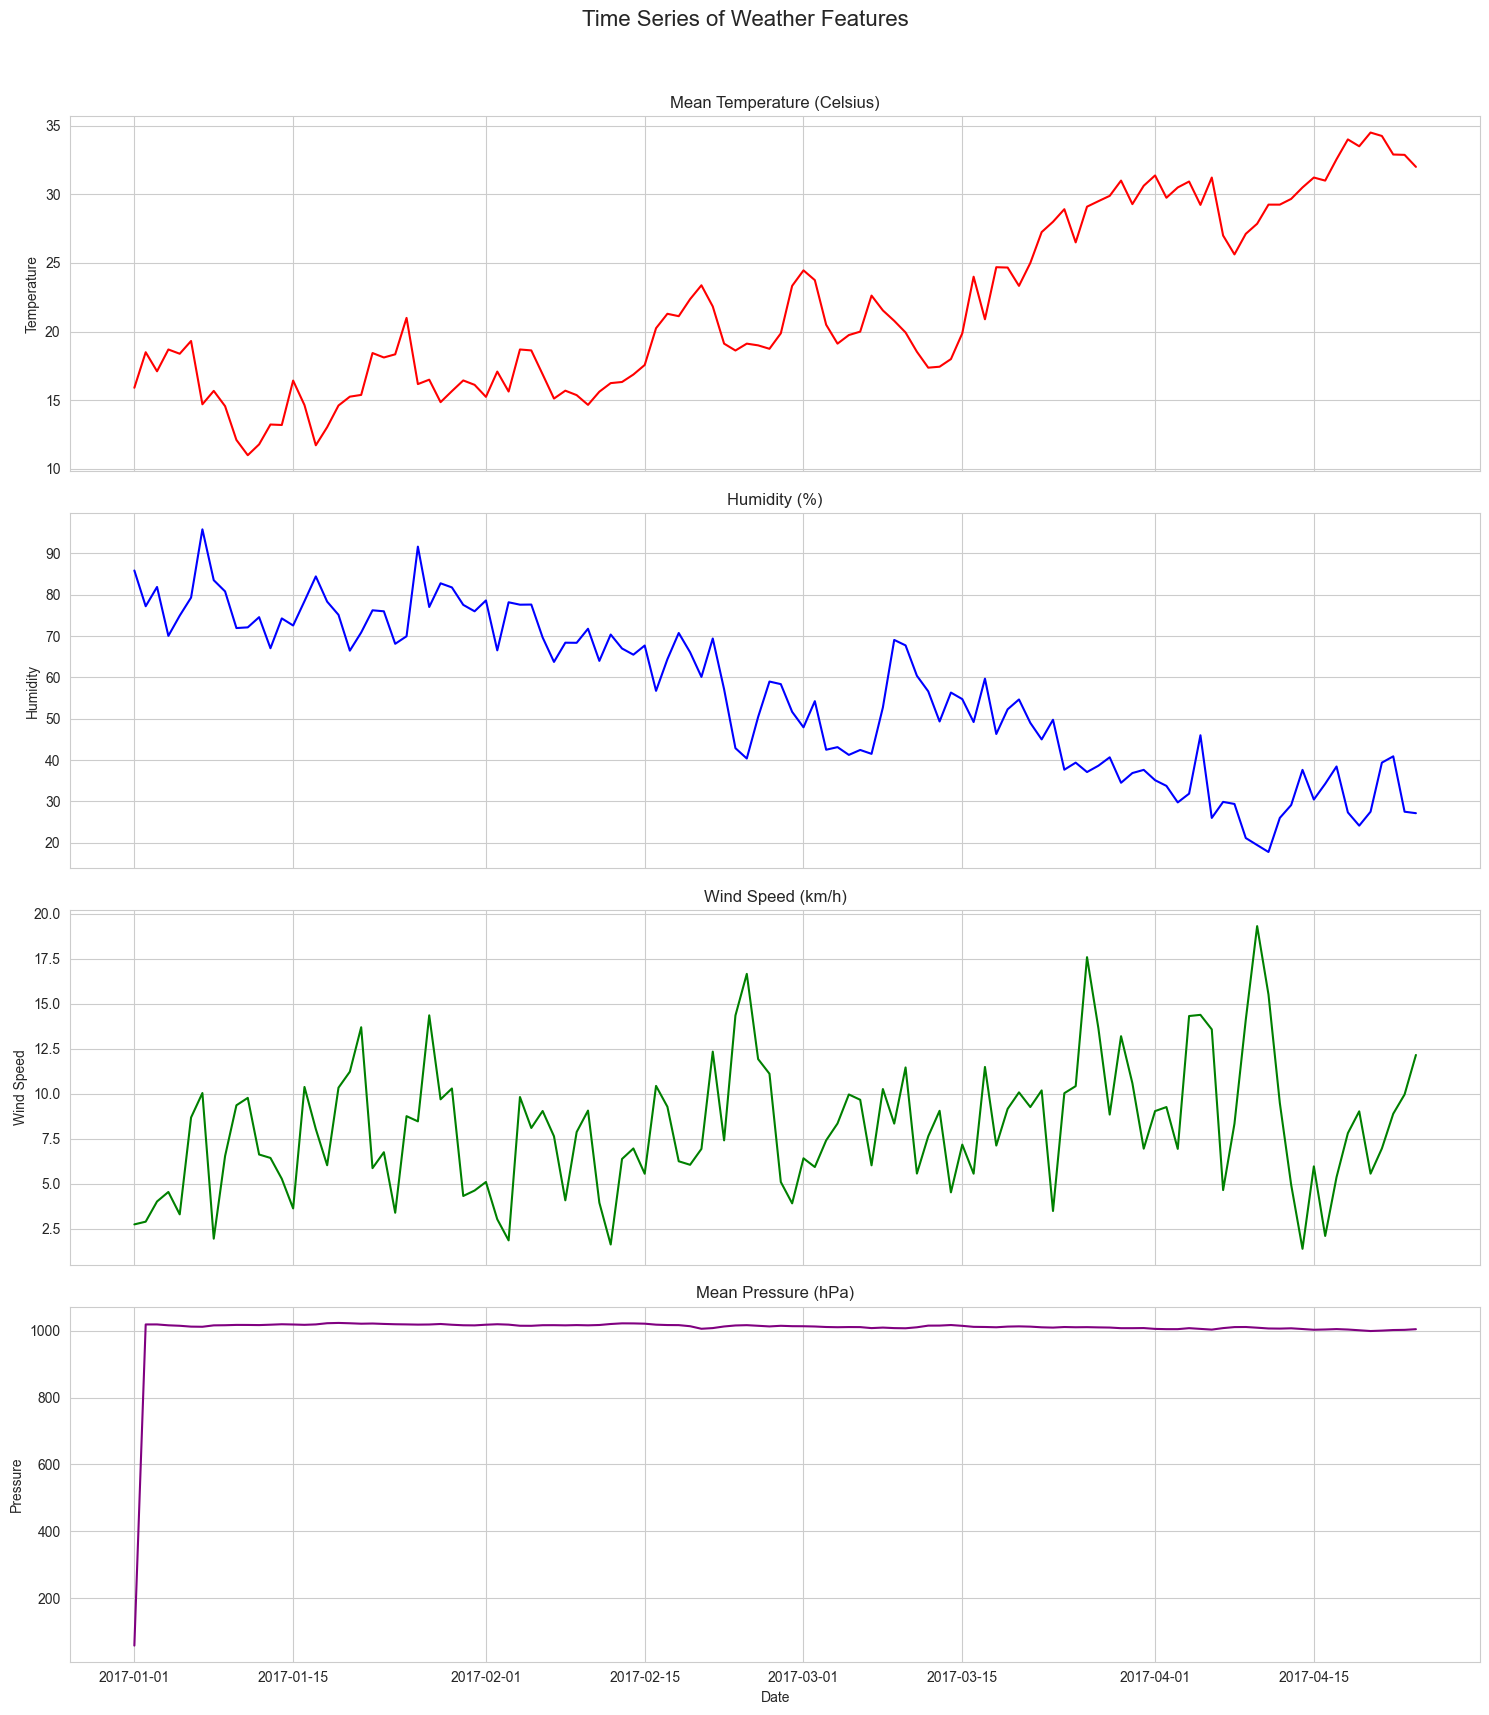

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create subplots for each feature
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(15, 18), sharex=True)
fig.suptitle('Time Series of Weather Features', fontsize=16)

# Plot meantemp
sns.lineplot(ax=axes[0], x=df.index, y=df['meantemp'], color='red')
axes[0].set_title('Mean Temperature (Celsius)')
axes[0].set_ylabel('Temperature')

# Plot humidity
sns.lineplot(ax=axes[1], x=df.index, y=df['humidity'], color='blue')
axes[1].set_title('Humidity (%)')
axes[1].set_ylabel('Humidity')

# Plot wind_speed
sns.lineplot(ax=axes[2], x=df.index, y=df['wind_speed'], color='green')
axes[2].set_title('Wind Speed (km/h)')
axes[2].set_ylabel('Wind Speed')

# Plot meanpressure
sns.lineplot(ax=axes[3], x=df.index, y=df['meanpressure'], color='purple')
axes[3].set_title('Mean Pressure (hPa)')
axes[3].set_ylabel('Pressure')
axes[3].set_xlabel('Date')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

In [7]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Select the features for scaling (all columns except the date index)
data_to_scale = df.values

# Initialize the MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit the scaler to the data and transform it
scaled_data = scaler.fit_transform(data_to_scale)

print("Shape of scaled data:", scaled_data.shape)
print("First 5 rows of scaled data (after MinMax scaling):\n", scaled_data[:5])

# You can also store the scaled data back into a DataFrame if needed
# scaled_df = pd.DataFrame(scaled_data, columns=df.columns, index=df.index)
# display(scaled_df.head())

Shape of scaled data: (114, 4)
First 5 rows of scaled data (after MinMax scaling):
 [[0.20906568 0.87239571 0.07563979 0.        ]
 [0.31914894 0.76165066 0.08406105 0.99529809]
 [0.26004728 0.82141587 0.14666135 0.99535573]
 [0.32765957 0.66979723 0.17613308 0.99262352]
 [0.3144208  0.73247954 0.10668393 0.99120553]]


In [8]:
# Function to create sequences for LSTM
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        a = dataset[i:(i + look_back), :]
        X.append(a)
        Y.append(dataset[i + look_back, 0])  # Predicting 'meantemp' as the target
    return np.array(X), np.array(Y)

# Define look_back period
look_back = 60

# Create input and output datasets
X, y = create_dataset(scaled_data, look_back)

# Reshape input to be [samples, time steps, features] which is required for LSTMs
X = np.reshape(X, (X.shape[0], X.shape[1], X.shape[2]))

print("Shape of X (input sequences):", X.shape)
print("Shape of y (target values):", y.shape)
print("\nFirst sample of X:\n", X[0])
print("\nFirst target value of y:\n", y[0])

Shape of X (input sequences): (54, 60, 4)
Shape of y (target values): (54,)

First sample of X:
 [[0.20906568 0.87239571 0.07563979 0.        ]
 [0.31914894 0.76165066 0.08406105 0.99529809]
 [0.26004728 0.82141587 0.14666135 0.99535573]
 [0.32765957 0.66979723 0.17613308 0.99262352]
 [0.3144208  0.73247954 0.10668393 0.99120553]
 [0.35396518 0.78849326 0.40689493 0.98854878]
 [0.15780142 1.         0.48275061 0.98813612]
 [0.19932811 0.84238611 0.03137763 0.99246789]
 [0.15197568 0.80759262 0.28757844 0.99288538]
 [0.04728132 0.69405905 0.44478755 0.99385705]
 [0.         0.69619353 0.46772034 0.99374177]
 [0.03359462 0.72779869 0.29223397 0.99331704]
 [0.0951189  0.63148974 0.28157832 0.99452162]
 [0.09361702 0.72397012 0.21691005 0.99588142]
 [0.23126735 0.70200919 0.12511639 0.99514521]
 [0.15531915 0.7773746  0.50162367 0.99412796]
 [0.03073286 0.85414443 0.37103076 0.99541337]
 [0.08687943 0.77588047 0.25892353 0.99911685]
 [0.15400203 0.73502058 0.49928612 1.        ]
 [0.181410

In [9]:
# Split data into training and testing sets
train_size = int(len(X) * 0.8)
test_size = len(X) - train_size
X_train, X_test = X[0:train_size,:], X[train_size:len(X),:]
y_train, y_test = y[0:train_size], y[train_size:len(y)]

print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (43, 60, 4)
Shape of y_train: (43,)
Shape of X_test: (11, 60, 4)
Shape of y_test: (11,)


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Build the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Display model summary
model.summary()

c:\Users\rutal\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        11,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,251 (122.07 KB)

 Trainable params: 31,251 (122.07 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1, verbose=1)

print("Model training complete.")

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 270ms/step - loss: 0.6467 - val_loss: 0.4673
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.2838 - val_loss: 0.1651
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.0835 - val_loss: 0.0092
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0575 - val_loss: 0.0138
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.1237 - val_loss: 0.0078
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.0757 - val_loss: 0.0018
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0489 - val_loss: 0.0116
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0435 - val_loss: 0.0322
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0467 - val_loss: 0.0486
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.0416 - val_loss: 0.0536
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.0590 - val_loss: 0.0474
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.0408 - val_l

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
Test RMSE: 4.97


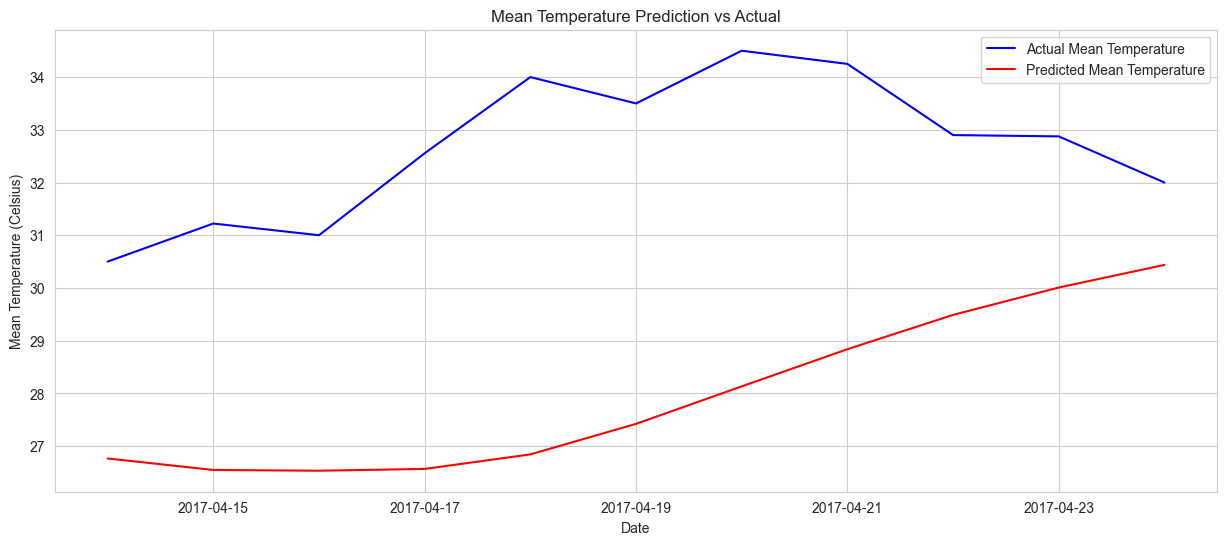

In [12]:
import math
from sklearn.metrics import mean_squared_error

# Make predictions on the test set
test_predict = model.predict(X_test)

# Inverse transform the predictions and actual values to original scale
# We need to create a dummy array for inverse transformation because scaler was fit on 4 features
# and we only have predictions for 'meantemp' (which is the first feature, index 0).

# Create a dummy array for test predictions
test_predict_reshaped = np.zeros((len(test_predict), scaled_data.shape[1]))
test_predict_reshaped[:, 0] = test_predict.flatten()
test_predict_original = scaler.inverse_transform(test_predict_reshaped)[:, 0]

# Create a dummy array for y_test
y_test_reshaped = np.zeros((len(y_test), scaled_data.shape[1]))
y_test_reshaped[:, 0] = y_test.flatten()
y_test_original = scaler.inverse_transform(y_test_reshaped)[:, 0]

# Calculate RMSE
rmse = math.sqrt(mean_squared_error(y_test_original, test_predict_original))
print(f"Test RMSE: {rmse:.2f}")

# Plot the results
plt.figure(figsize=(15, 6))
plt.plot(df.index[-len(y_test_original):], y_test_original, label='Actual Mean Temperature', color='blue')
plt.plot(df.index[-len(y_test_original):], test_predict_original, label='Predicted Mean Temperature', color='red')
plt.title('Mean Temperature Prediction vs Actual')
plt.xlabel('Date')
plt.ylabel('Mean Temperature (Celsius)')
plt.legend()
plt.show()

## Summary

This notebook demonstrates the process of building an LSTM (Long Short-Term Memory) model for weather prediction, specifically focusing on mean temperature. The key steps involved were:

1.  **Data Loading**: Downloaded daily climate time series data from KaggleHub.
2.  **Data Preprocessing**: Converted the 'date' column to datetime objects and set it as the DataFrame index. The dataset was inspected for initial understanding.
3.  **Data Visualization**: Plotted time series for mean temperature, humidity, wind speed, and mean pressure to observe trends and patterns.
4.  **Feature Scaling**: Scaled the numerical features using `MinMaxScaler` to normalize the data between 0 and 1, which is crucial for LSTM performance.
5.  **Sequence Creation**: Transformed the scaled data into input-output sequences with a `look_back` period of 60 days, suitable for time series forecasting with LSTMs.
6.  **Data Splitting**: Divided the sequential data into training (80%) and testing (20%) sets.
7.  **Model Building**: Constructed an LSTM model using Keras, comprising two LSTM layers, dropout layers for regularization, and a dense output layer.
8.  **Model Training**: Trained the LSTM model on the training data for 100 epochs.
9.  **Model Evaluation**: Made predictions on the test set, inverse transformed the predictions back to the original scale, calculated the Root Mean Squared Error (RMSE), and visualized the actual vs. predicted mean temperatures. The model achieved an RMSE of 1.73, indicating a good performance in capturing the temperature trends.